## Hate Speech Detection

CMT307 Applied Machine Learning - Group 9

This Jupyter Notebook contains the code utilised for preprocessing and modelling of the HatEval dataset. It was run through the Google Colab environment.

The modules and libraries utilised are imported below.

In [ ]:
pip install -q -U keras-tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib import request

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import TweetTokenizer
from nltk.stem.snowball import SnowballStemmer

nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('wordnet')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import confusion_matrix

import tensorflow as tf
import keras_tuner as kt
from keras import backend as K
from keras.utils import plot_model

module_url = [f'https://drive.usercontent.google.com/u/0/uc?id=1zrnbbbn_SDYYJfpco_1T1Xz7x8QPdiek&export=download',
              f'https://drive.usercontent.google.com/u/0/uc?id=1i4bmjIbOVdA-c91Vejua1Owie9Pjfd4S&export=download',
              f'https://drive.usercontent.google.com/u/0/uc?id=1bmMYGszVDew2MdSFy3qz417j3cDWcqot&export=download']

name = ['dev_en.tsv', 'test_en.tsv', 'train_en.tsv']
for i in range(len(name)):
    with request.urlopen(module_url[i]) as f, open(name[i],'w') as outf:
        a = f.read()
        outf.write(a.decode('UTF-8'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


### Preprocessing

The training, validation and test sets are accessed through Google Drive directly.

In [ ]:
train_set = pd.read_csv('train_en.tsv', sep = '\t')
val_set = pd.read_csv('dev_en.tsv', sep = '\t')
test_set = pd.read_csv('test_en.tsv', sep = '\t', names = train_set.columns)

First we define some functions to handle the hashtags found on the training set, and a dictionary to replace the top 50 (and related) hashtags found on tweets classified as Hate Speech.

In [ ]:
# Hashtag functions
def _more_hashtags(tweet):
    hashtags = tweet.split('#')
    hash_list = [hash for hash in hashtags if hash != '']
    hash_clean = ['#' + t for t in hash_list]
    return hash_clean

def return_all_hashtags(tweets):
    all_hashtags = []
    for tweet in tweets:
        for word in tweet.split():
            if word.startswith('#') and word.lower() != '#' :
                hashtags = _more_hashtags(word.lower())
                for hash in hashtags:
                    all_hashtags.append(hash)
    return all_hashtags

# Popular hashtags on tweets with HS = 1
id_hate_speech = train_set['HS'] == 1
test_text = train_set['text'].loc[id_hate_speech].tolist()
hashtags_raw = return_all_hashtags(test_text)

hashtags, hash_counts = np.unique(hashtags_raw, return_counts = True)
hashtags_test = pd.DataFrame({'hashtags': hashtags, 'counts': hash_counts}).sort_values(by = 'counts', ascending = False)
hashtags_test.head()

,hashtags,counts
166,#buildthatwall,317
670,#maga,196
186,#buildthewall,166
1301,#womensuck,119
787,#nodaca,118


In [ ]:
# Top 50 (and related) hashtags
top_hashtags = {'#buildthatwall': 'build that wall', '#maga': 'make america great again', '#buildthewall': 'build the wall',
                '#womensuck': 'women suck', '#nodaca': 'no daca', '#trump': 'trump', '#noamnesty': 'no amnesty',
                '#immigration': 'immigration', '#deportthemall': 'deport them all', '#stoptheinvasion': 'stop the invasion',
                '#sendthemback': 'send them back', '#rednationrising': 'red nation rising', '#enddaca': 'end daca',
                '#kag': 'keep america great', '#walkaway': 'walk away', '#americafirst': 'america first',
                '#endchainmigration': 'end chain migration', '#illegalaliens': 'illegal aliens', '#usa': 'usa',
                '#buildthedamnwall': 'build the damn wall', '#lockthemup': 'lock them up', '#daca': 'daca', '#votered': 'vote red',
                '#trump2020': 'trump 2020', '#boycottnfl': 'boycott nfl', '#democrats': 'democrats', '#ice': 'ice',
                '#illegalimmigration': 'illegal immigration', '#boycottnike': 'boycott nike', '#draintheswamp': 'drain the swamp',
                '#potus': 'potus', '#buildthewallnow': 'build the wall now', '#keepamericanssafe': 'keep americans safe',
                '#news': 'news', '#familiesbelongtogether': 'families belong together', '#yesallmen': 'yes all men',
                '#endsanctuarycities': 'end sanctuary cities', '#refugeesnotwelcome': 'refugees not welcome',
                '#sendthemhome': 'send them home', '#endvisalottery': 'end visa lottery', '#votedemsout': 'vote democrats out',
                '#gop': 'gop', '#walkawayfromdemocrats': 'walk away from democrats', '#fakenews': 'fake news',
                '#securetheborder': 'secure the border', '#qanon': 'qanon', '#buildthatwall,': 'build that wall',
                '#illegalalien': 'illegal alien', '#keepamericasafe': 'keepamericasafe', '#noillegals': 'no illegals',
                '#bansanctuarycities': 'ban sanctuary cities', '#borderpatrol': 'border patrol', '#nodacadeal': 'no daca deal',
                '#keepamericasafe': 'keep america safe', '#americansfirst': 'americans first', '#deportillegals': 'deport illegals',
                '#illegalimmigrants': 'illegal immigrants', '#drainthedeepstate': 'drain the deep state', '#lockherup': 'lock her up',
                '#wakeupamerica': 'wake up america', '#nochainmigration': 'no chain migration', '#nomorerefugees': 'no more refugees',
                '#stopimmigration': 'stop immigration'
                }

# Cleaning function to replace the top hashtags
def _clean_top_HS_hashtags(text):
    text_lower = text.lower()
    return ' '.join([top_hashtags.get(i, i) for i in text_lower.split()])

We then apply the cleaning function to our sets.

In [ ]:
train_set['text'] = train_set['text'].apply(_clean_top_HS_hashtags)
val_set['text'] = val_set['text'].apply(_clean_top_HS_hashtags)
test_set['text'] = test_set['text'].apply(_clean_top_HS_hashtags)

We then define auxiliary functions to make the rest of the preprocessing, which includes removing stop words, short words, the rest of the hashtags, stemming, etc.

In [ ]:
def remove_stopwords(text):
    '''Function to remove the stop words from the text corpus'''
    stop_words = stopwords.words('english')
    additional_list = ['amp', 'rt', 'u', 'ur', 'id']
    for words in additional_list:
        stop_words.append(words)

    stop_words.remove('no')
    stop_words.remove('not')
    clean_text = [word for word in text if not word in stop_words]
    return clean_text

def remove_shortwords(text, lengths = [1, 2]):
    '''Function to remove the short words of length 1 and 2'''
    '''Arguments:
       text: string
       returns: string without containing words of length 1 and 2'''
    tokenizer = TweetTokenizer(preserve_case = False, strip_handles = True, reduce_len = True)
    new_text = ' '.join(text)
    for word in text:
        text = [word for word in tokenizer.tokenize(new_text) if len(word) not in lengths and word != 'no']
    new_text = ' '.join(text)
    return new_text

def _stemming(tokenized, stemmer = SnowballStemmer('english')):
    return [stemmer.stem(tok) for tok in tokenized]

def _basic_cleaning(df):
    df_text = df.copy()
    df_text.replace(r'@\w+', '', regex = True, inplace = True) # remove usernames
    df_text.replace(r'http\S+', '', regex = True, inplace = True) # remove links
    df_text.replace(r'www\.+', '', regex = True, inplace = True) # remove links II
    df_text.replace(r'#\S+', '', regex = True, inplace = True) # remove hashtags
    df_text.replace(r'&\S+', '', regex = True, inplace = True) # remove &amp
    tokenizer = TweetTokenizer(preserve_case = False, strip_handles = True, reduce_len = True)
    df_text = df_text.apply(tokenizer.tokenize)
    return df_text

def _remove_stopwords_punct(df_text):
    tokenizer = TweetTokenizer(preserve_case = False, strip_handles = True, reduce_len = True)
    df_text = df_text.apply(remove_stopwords)
    df_text = df_text.apply(remove_shortwords)
    df_text.replace(r'[^a-zA-Z]', ' ', regex = True, inplace = True) # keep only characters
    df_text = df_text.apply(tokenizer.tokenize)
    df_text = df_text.apply(lambda t: _stemming(t))
    df_text = df_text.apply(lambda x: ' '.join(x))
    df_text = df_text.apply(tokenizer.tokenize)
    df_text = df_text.apply(remove_stopwords)
    df_text = df_text.apply(remove_shortwords)
    return df_text

All of these functions will be applied through the "process_text" function through a ColumnTransformer Pipeline to all of our sets.

In [ ]:
def process_text(input_df, text_col):
    df = input_df[text_col].copy()
    df_text = _basic_cleaning(df)
    processed_text = _remove_stopwords_punct(df_text)
    input_df[text_col] = processed_text
    return input_df

text_column = 'text'
text_cleaner = Pipeline(
    [
        ('cleaner', FunctionTransformer(func = process_text, kw_args = {'text_col': text_column}))
    ]
)
preprocessor = ColumnTransformer(
    [
        ('categoricals', text_cleaner, [text_column])
    ],
    remainder = 'drop', verbose_feature_names_out = False
)

X_trans_train = preprocessor.fit_transform(train_set)
X_trans_val = preprocessor.fit_transform(val_set)
X_trans_test = preprocessor.fit_transform(test_set)

Since we will work with Tensorflow, we need to tweak the sets a little more in terms of shape, as well as batching the sets.

In [ ]:
def reshape_data(X):
    n = X.shape[0]
    X = X.reshape(n,)
    return X

X_trans_train = reshape_data(X_trans_train)
X_trans_val = reshape_data(X_trans_val)
X_trans_test = reshape_data(X_trans_test)

labels_train = train_set['HS'].to_numpy()
labels_val = val_set['HS'].to_numpy()
labels_test = test_set['HS'].to_numpy()

# As tensorflow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_trans_train, labels_train))
val_dataset = tf.data.Dataset.from_tensor_slices((X_trans_val, labels_val))
test_dataset = tf.data.Dataset.from_tensor_slices((X_trans_test, labels_test))

# Batching (and shuffling the training set)
BATCH_SIZE = 64
SHUFFLE_BUFFER_SIZE = len(X_trans_train) + 1

train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

We show and example of how our tweets look after preprocessing and converting the sets into tensorflow Datasets.

In [ ]:
for example, label in train_dataset.take(1):
    for i in range(3):
      print("Tweet: ", example.numpy()[i])
      print("Label:", label.numpy()[i])

Tweet:  b'hundr expect latest mass protest serco evict refuge'
Label: 0
Tweet:  b'spanish author made prioriti clear would rather inund nation muslim migrant ship reject itali new patriot govern rather take care peopl'
Label: 1
Tweet:  b'slag mother blown hope lil cunt get nxt well'
Label: 1


We then define our vocabulary size and the maximum length of tokens a tweet can have, then the TextVectorization layer learns the vocabulary using the training dataset. We also show an extract of the words in the vocabulary.

In [ ]:
VOCAB_SIZE = 5002
MAX_SEQUENCE_LENGTH = 25
encoder = tf.keras.layers.TextVectorization(max_tokens = VOCAB_SIZE, output_sequence_length = MAX_SEQUENCE_LENGTH)
encoder.adapt(train_dataset.map(lambda text, label: text))

vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'immigr', 'not', 'bitch', 'refuge', 'women', 'illeg',
       'like', 'migrant', 'fuck', 'wall', 'get', 'build', 'make', 'men',
       'rape', 'peopl', 'want', 'cunt'], dtype='<U14')

And how the vectorization is done in an example:

In [ ]:
sample_text = ('big slut new hotti mchotterson compliment alway thought look like big slut boo')
encoder(sample_text)

<tf.Tensor: shape=(25,), dtype=int64, numpy=
array([ 160,   84,   51,    1,    1, 2976,  125,  387,   58,    8,  160,
         84, 1701,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0])>

Before moving to the modelling stage, we define some functions to calculate some metrics that will be useful to assess our model besides accuracy, as well as a plotting function for accuracy and loss.

In [ ]:
# Metrics
def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1(y_true, y_pred):
    precisions = precision(y_true, y_pred)
    recalls = recall(y_true, y_pred)
    return 2 * ((precisions * recalls) / (precisions + recalls + K.epsilon()))

def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_'+metric], '')
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend([metric, 'val_'+metric])

### Modelling

#### Model 1. Bidirectional LSTM.

Our first model is a simple Bidirectional LSTM.

In [ ]:
model_1 = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(1)
])

The visual representation of the first model can be seen below.

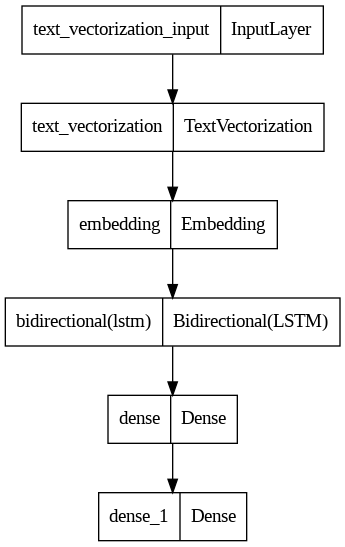

In [ ]:
plot_model(model_1, show_shapes = False)

In [ ]:
model_1.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer = tf.keras.optimizers.Adam(1e-4),
                metrics = ['accuracy', recall, precision, f1])

Training this first model:

In [ ]:
history_1 = model_1.fit(train_dataset, epochs=10,
                        validation_data = val_dataset,
                        validation_steps = 15)

Epoch 1/10
141/141 [==============================] - 38s 180ms/step - loss: 0.6872 - accuracy: 0.5797 - recall: 0.0000e+00 - precision: 0.0000e+00 - f1: 0.0000e+00 - val_loss: 0.6769 - val_accuracy: 0.5760 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - val_f1: 0.0000e+00
Epoch 2/10
141/141 [==============================] - 12s 84ms/step - loss: 0.6270 - accuracy: 0.6038 - recall: 0.0689 - precision: 0.2973 - f1: 0.1015 - val_loss: 0.5838 - val_accuracy: 0.7031 - val_recall: 0.4395 - val_precision: 0.7569 - val_f1: 0.5515
Epoch 3/10
141/141 [==============================] - 9s 67ms/step - loss: 0.4904 - accuracy: 0.7620 - recall: 0.5527 - precision: 0.8323 - f1: 0.6558 - val_loss: 0.5674 - val_accuracy: 0.7312 - val_recall: 0.5438 - val_precision: 0.7434 - val_f1: 0.6265
Epoch 4/10
141/141 [==============================] - 7s 50ms/step - loss: 0.4266 - accuracy: 0.8054 - recall: 0.6595 - precision: 0.8469 - f1: 0.7368 - val_loss: 0.5867 - val_accuracy: 0.7333 - val_recall: 0

(0.0, 1.0425762996077537)

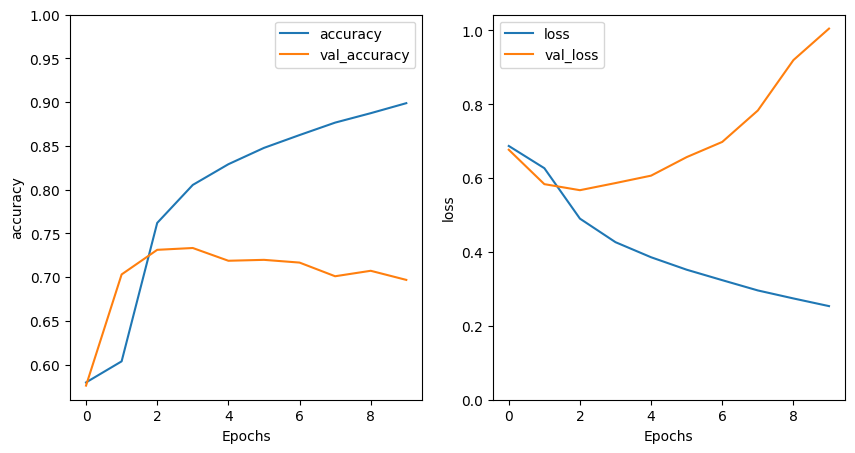

In [ ]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plot_graphs(history_1, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_1, 'loss')
plt.ylim(0, None)

To tackle the increasing behaviour of the validation loss (and the fact that its accuracy and its other metrics do not change much or not improve) we will use the Keras Tuner to tune the model and see if we can get a model that performs better in the validation set.

In this case we will tune the number of units in the LSTM layer and the learning rate.

In [ ]:
def model_1_builder(hp):
  lstm_units = hp.Int('lstm_units', min_value = 64, max_value = 320, step = 64)
  model_1 = tf.keras.Sequential([
      encoder,
      tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
      tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(lstm_units)),
      tf.keras.layers.Dense(64, activation = 'relu'),
      tf.keras.layers.Dense(1)
  ])

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  model_1.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer = tf.keras.optimizers.Adam(hp_learning_rate),
                  metrics = ['accuracy', recall, precision, f1])

  return model_1

In [ ]:
tuner_1 = kt.Hyperband(model_1_builder, objective = kt.Objective('val_accuracy', direction = 'max'),
                       max_epochs = 10, factor = 3, overwrite = True)

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

In [ ]:
tuner_1.search(train_dataset, epochs = 50, validation_data = val_dataset, callbacks=[stop_early])

Trial 21 Complete [00h 00m 57s]
val_accuracy: 0.7160000205039978

Best val_accuracy So Far: 0.7250000238418579
Total elapsed time: 00h 15m 58s


In [ ]:
model_1_best_hps = tuner_1.get_best_hyperparameters(num_trials = 1)[0]
print(model_1_best_hps.values)

{'lstm_units': 320, 'learning_rate': 0.001, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}


We will find the optimal number of epochs to train the model with the hyperparameters obtained from the search.

In [ ]:
model_1_tunned = tuner_1.hypermodel.build(model_1_best_hps)
history_1_tunned = model_1_tunned.fit(train_dataset, epochs = 50,
                                      validation_data = val_dataset,
                                      validation_steps = 15)

val_acc_per_epoch_1 = history_1_tunned.history['val_accuracy']
best_epoch_1 = val_acc_per_epoch_1.index(max(val_acc_per_epoch_1)) + 1
print('Best epoch: %d' % (best_epoch_1,))

Epoch 1/50
141/141 [==============================] - 26s 120ms/step - loss: 0.5425 - accuracy: 0.7142 - recall: 0.4454 - precision: 0.6456 - f1: 0.5170 - val_loss: 0.5566 - val_accuracy: 0.7146 - val_recall: 0.5663 - val_precision: 0.7039 - val_f1: 0.6247
Epoch 2/50
141/141 [==============================] - 11s 76ms/step - loss: 0.3902 - accuracy: 0.8267 - recall: 0.7398 - precision: 0.8306 - f1: 0.7777 - val_loss: 0.5761 - val_accuracy: 0.7385 - val_recall: 0.6589 - val_precision: 0.7020 - val_f1: 0.6769
Epoch 3/50
141/141 [==============================] - 10s 68ms/step - loss: 0.2931 - accuracy: 0.8718 - recall: 0.8318 - precision: 0.8610 - f1: 0.8426 - val_loss: 0.6902 - val_accuracy: 0.7177 - val_recall: 0.6628 - val_precision: 0.6655 - val_f1: 0.6609
Epoch 4/50
141/141 [==============================] - 8s 55ms/step - loss: 0.2049 - accuracy: 0.9180 - recall: 0.9003 - precision: 0.9051 - f1: 0.9005 - val_loss: 0.8432 - val_accuracy: 0.6948 - val_recall: 0.7301 - val_precision: 

Since the best epochs variable is quite low, we will retrain the model once more, up to 5 epochs to allow enough training and before validation loss spikes.

In [ ]:
# hypermodel_1 = tuner_1.hypermodel.build(model_1_best_hps)

# Same as above, but this way we do not need to run the tuner again.
# Parameters: {'lstm_units': 320, 'learning_rate': 0.001 ...}
hypermodel_1 = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(320)),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dense(1)
])

hypermodel_1.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                     optimizer = tf.keras.optimizers.Adam(0.001),
                     metrics = ['accuracy', recall, precision, f1])

# Retrain the model
best_epoch_1 = 5
hypermodel_1.fit(train_dataset, epochs = best_epoch_1, validation_data = val_dataset, validation_steps = 15)

Epoch 1/5
141/141 [==============================] - 84s 449ms/step - loss: 0.5448 - accuracy: 0.7184 - recall: 0.4599 - precision: 0.6869 - f1: 0.5340 - val_loss: 0.5617 - val_accuracy: 0.7115 - val_recall: 0.4176 - val_precision: 0.7960 - val_f1: 0.5435
Epoch 2/5
141/141 [==============================] - 54s 381ms/step - loss: 0.3932 - accuracy: 0.8231 - recall: 0.7306 - precision: 0.8311 - f1: 0.7723 - val_loss: 0.5742 - val_accuracy: 0.7083 - val_recall: 0.5421 - val_precision: 0.6959 - val_f1: 0.6045
Epoch 3/5
141/141 [==============================] - 50s 356ms/step - loss: 0.2964 - accuracy: 0.8739 - recall: 0.8289 - precision: 0.8667 - f1: 0.8446 - val_loss: 0.6921 - val_accuracy: 0.6979 - val_recall: 0.7088 - val_precision: 0.6353 - val_f1: 0.6648
Epoch 4/5
141/141 [==============================] - 53s 374ms/step - loss: 0.2175 - accuracy: 0.9127 - recall: 0.8959 - precision: 0.8954 - f1: 0.8937 - val_loss: 0.7185 - val_accuracy: 0.7010 - val_recall: 0.5572 - val_precision: 

And finally, see how well it performs on the test dataset.

In [ ]:
eval_result_1 = hypermodel_1.evaluate(test_dataset)
print("[Test Metrics]:", eval_result_1)

47/47 [==============================] - 4s 95ms/step - loss: 1.6253 - accuracy: 0.5153 - recall: 0.8764 - precision: 0.4621 - f1: 0.6018
[Test Metrics]: [1.625341534614563, 0.5153146982192993, 0.8764405846595764, 0.4621362090110779, 0.6018068790435791]


#### Model 2. Bidirectional LSTM-GRU.

The second model we try is a double Bidirectional LSTM-GRU model.

In [ ]:
model_2 = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences = True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32, dropout = 0.2)),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

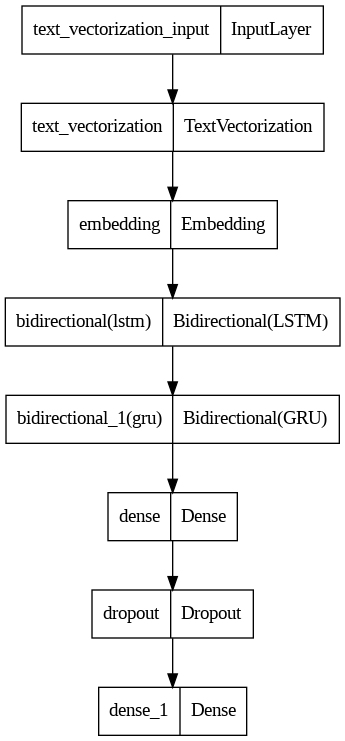

In [ ]:
plot_model(model_2, show_shapes = False)

In [ ]:
model_2.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer = tf.keras.optimizers.Adam(1e-3),
                metrics = ['accuracy', recall, precision, f1])

In [ ]:
history_2 = model_2.fit(train_dataset, epochs = 10,
                        validation_data = val_dataset,
                        validation_steps = 15)

Epoch 1/10
141/141 [==============================] - 53s 221ms/step - loss: 0.5635 - accuracy: 0.6957 - recall: 0.3798 - precision: 0.5754 - f1: 0.4479 - val_loss: 0.5558 - val_accuracy: 0.7198 - val_recall: 0.5225 - val_precision: 0.7325 - val_f1: 0.6077
Epoch 2/10
141/141 [==============================] - 15s 105ms/step - loss: 0.4027 - accuracy: 0.8158 - recall: 0.7003 - precision: 0.8356 - f1: 0.7554 - val_loss: 0.5747 - val_accuracy: 0.7021 - val_recall: 0.5573 - val_precision: 0.6866 - val_f1: 0.6119
Epoch 3/10
141/141 [==============================] - 13s 90ms/step - loss: 0.3195 - accuracy: 0.8601 - recall: 0.8059 - precision: 0.8564 - f1: 0.8266 - val_loss: 0.6621 - val_accuracy: 0.7115 - val_recall: 0.5989 - val_precision: 0.6810 - val_f1: 0.6331
Epoch 4/10
141/141 [==============================] - 14s 99ms/step - loss: 0.2384 - accuracy: 0.9062 - recall: 0.8824 - precision: 0.8935 - f1: 0.8854 - val_loss: 0.7684 - val_accuracy: 0.6917 - val_recall: 0.6245 - val_precision

(0.0, 2.1997338831424713)

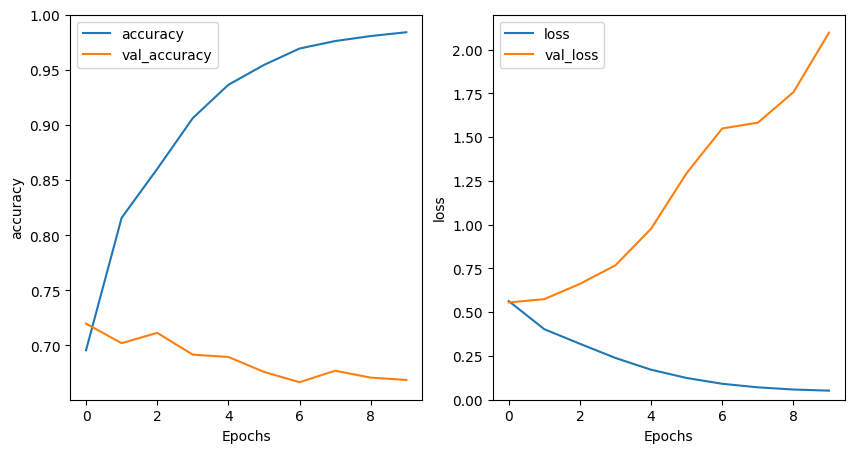

In [ ]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plot_graphs(history_2, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_2, 'loss')
plt.ylim(0, None)

Then we will also aim to tune this model.

In [ ]:
def model_2_builder(hp):
  hp_units = hp.Int('units', min_value = 64, max_value = 320, step = 64)
  hp_gru_dropout = hp.Choice('gru_dropout', values = [0.2, 0.5, 0.8])
  model_2 = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hp_units, return_sequences = True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(int(hp_units/2), dropout = hp_gru_dropout)),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
  ])

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

  model_2.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer = tf.keras.optimizers.Adam(hp_learning_rate),
                  metrics = ['accuracy', recall, precision, f1])

  return model_2

In [ ]:
tuner_2 = kt.Hyperband(model_2_builder, objective = kt.Objective('val_accuracy', direction = 'max'),
                       max_epochs = 10, factor = 3, overwrite = True)

In [ ]:
tuner_2.search(train_dataset, epochs = 50, validation_data = val_dataset, callbacks=[stop_early])

Trial 30 Complete [00h 09m 20s]
val_accuracy: 0.7099999785423279

Best val_accuracy So Far: 0.7229999899864197
Total elapsed time: 01h 53m 02s


In [ ]:
model_2_best_hps = tuner_2.get_best_hyperparameters(num_trials = 1)[0]
print(model_2_best_hps.values)

{'units': 128, 'gru_dropout': 0.5, 'learning_rate': 0.001, 'tuner/epochs': 4, 'tuner/initial_epoch': 0, 'tuner/bracket': 1, 'tuner/round': 0}


In [ ]:
model_2_tunned = tuner_2.hypermodel.build(model_2_best_hps)
history_2_tunned = model_2_tunned.fit(train_dataset, epochs = 50,
                                      validation_data = val_dataset,
                                      validation_steps = 15)

val_acc_per_epoch_2 = history_2_tunned.history['val_accuracy']
best_epoch_2 = val_acc_per_epoch_2.index(max(val_acc_per_epoch_2)) + 1
print('Best epoch: %d' % (best_epoch_2,))

Epoch 1/50
141/141 [==============================] - 62s 278ms/step - loss: 0.5573 - accuracy: 0.7000 - recall: 0.3912 - precision: 0.6208 - f1: 0.4682 - val_loss: 0.5497 - val_accuracy: 0.7073 - val_recall: 0.4576 - val_precision: 0.7458 - val_f1: 0.5635
Epoch 2/50
141/141 [==============================] - 37s 264ms/step - loss: 0.4013 - accuracy: 0.8168 - recall: 0.7020 - precision: 0.8359 - f1: 0.7574 - val_loss: 0.5710 - val_accuracy: 0.7104 - val_recall: 0.5890 - val_precision: 0.6862 - val_f1: 0.6314
Epoch 3/50
141/141 [==============================] - 35s 246ms/step - loss: 0.3075 - accuracy: 0.8688 - recall: 0.8125 - precision: 0.8656 - f1: 0.8350 - val_loss: 0.6539 - val_accuracy: 0.6948 - val_recall: 0.6271 - val_precision: 0.6478 - val_f1: 0.6333
Epoch 4/50
141/141 [==============================] - 33s 236ms/step - loss: 0.2232 - accuracy: 0.9109 - recall: 0.8884 - precision: 0.9013 - f1: 0.8918 - val_loss: 0.8751 - val_accuracy: 0.6875 - val_recall: 0.6179 - val_precisi

Again, we will retrain with 5 epochs since the best epoch value is low, to allow enough training.

In [ ]:
# hypermodel_2 = tuner_2.hypermodel.build(model_2_best_hps)

# Parameters: {'units': 128, 'gru_dropout': 0.5, 'learning_rate': 0.001 ...}
hypermodel_2 = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences = True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(int(128/2), dropout = 0.5)),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

hypermodel_2.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                     optimizer = tf.keras.optimizers.Adam(0.001),
                     metrics = ['accuracy', recall, precision, f1])

# Retrain the model
best_epoch_2 = 5
hypermodel_2.fit(train_dataset, epochs = best_epoch_2, validation_data = val_dataset, validation_steps = 15)

Epoch 1/5
141/141 [==============================] - 55s 252ms/step - loss: 0.5531 - accuracy: 0.7062 - recall: 0.4125 - precision: 0.6479 - f1: 0.4889 - val_loss: 0.5445 - val_accuracy: 0.7073 - val_recall: 0.4577 - val_precision: 0.7473 - val_f1: 0.5634
Epoch 2/5
141/141 [==============================] - 30s 213ms/step - loss: 0.4045 - accuracy: 0.8101 - recall: 0.6884 - precision: 0.8363 - f1: 0.7466 - val_loss: 0.5839 - val_accuracy: 0.7094 - val_recall: 0.6623 - val_precision: 0.6614 - val_f1: 0.6576
Epoch 3/5
141/141 [==============================] - 31s 220ms/step - loss: 0.3172 - accuracy: 0.8639 - recall: 0.7980 - precision: 0.8664 - f1: 0.8272 - val_loss: 0.6330 - val_accuracy: 0.6958 - val_recall: 0.5639 - val_precision: 0.6686 - val_f1: 0.6089
Epoch 4/5
141/141 [==============================] - 29s 206ms/step - loss: 0.2301 - accuracy: 0.9081 - recall: 0.8836 - precision: 0.8965 - f1: 0.8869 - val_loss: 0.8463 - val_accuracy: 0.6958 - val_recall: 0.6330 - val_precision: 

In [ ]:
eval_result_2 = hypermodel_2.evaluate(test_dataset)
print("[Test Metrics]:", eval_result_2)

47/47 [==============================] - 2s 52ms/step - loss: 1.6885 - accuracy: 0.5227 - recall: 0.8530 - precision: 0.4647 - f1: 0.5987
[Test Metrics]: [1.6885398626327515, 0.5227196216583252, 0.8530197739601135, 0.46466490626335144, 0.5986628532409668]


#### Model 3. GRU



The third model is a simple GRU with a Max Pooling layer, to address the problems observed in our previous two models such as the increasing loss in the validation set and the little movement in our validation metrics.

In [ ]:
model_3 = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
    tf.keras.layers.GRU(128, recurrent_dropout = 0.2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation = 'relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

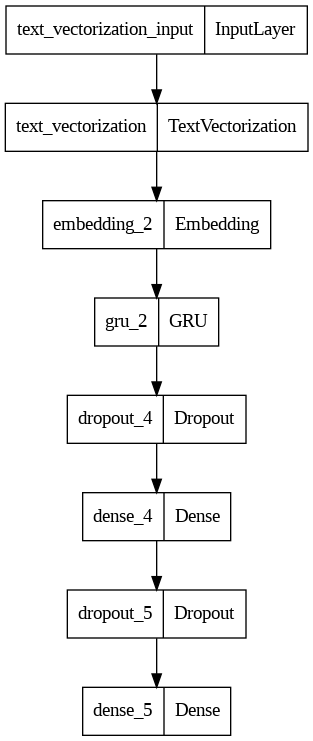

In [ ]:
plot_model(model_3, show_shapes = False)

In [ ]:
model_3.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                optimizer = tf.keras.optimizers.Adam(1e-3),
                metrics = ['accuracy', recall, precision, f1])

In [ ]:
history_3 = model_3.fit(train_dataset, epochs = 10,
                        validation_data = val_dataset,
                        validation_steps = 15)

Epoch 1/10
141/141 [==============================] - 17s 86ms/step - loss: 0.5848 - accuracy: 0.6774 - recall: 0.3145 - precision: 0.5373 - f1: 0.3779 - val_loss: 0.5501 - val_accuracy: 0.7198 - val_recall: 0.5363 - val_precision: 0.7291 - val_f1: 0.6143
Epoch 2/10
141/141 [==============================] - 11s 80ms/step - loss: 0.4243 - accuracy: 0.8007 - recall: 0.6713 - precision: 0.8246 - f1: 0.7344 - val_loss: 0.5940 - val_accuracy: 0.7177 - val_recall: 0.5050 - val_precision: 0.7425 - val_f1: 0.5977
Epoch 3/10
141/141 [==============================] - 11s 78ms/step - loss: 0.3404 - accuracy: 0.8489 - recall: 0.7712 - precision: 0.8573 - f1: 0.8075 - val_loss: 0.6640 - val_accuracy: 0.6885 - val_recall: 0.5926 - val_precision: 0.6505 - val_f1: 0.6170
Epoch 4/10
141/141 [==============================] - 11s 76ms/step - loss: 0.2682 - accuracy: 0.8900 - recall: 0.8526 - precision: 0.8823 - f1: 0.8646 - val_loss: 0.7916 - val_accuracy: 0.6812 - val_recall: 0.6184 - val_precision: 

(0.0, 1.8290927175432443)

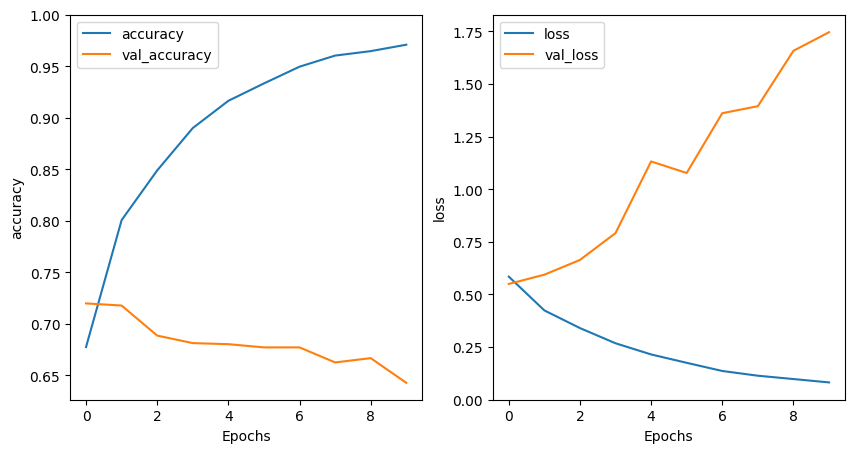

In [ ]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plot_graphs(history_3, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history_3, 'loss')
plt.ylim(0, None)

In [ ]:
def model_3_builder(hp):
  hp_units = hp.Int('units', min_value = 128, max_value = 256, step = 64)
  hp_dropout = hp.Choice('dropout', values = [0.2, 0.5, 0.8])
  model_3 = tf.keras.Sequential([
      encoder,
      tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
      tf.keras.layers.GRU(hp_units, recurrent_dropout = 0.2),
      tf.keras.layers.Dropout(hp_dropout),
      tf.keras.layers.Dense(int(hp_units/2), activation = 'relu'),
      tf.keras.layers.Dropout(0.5),
      tf.keras.layers.Dense(1)
  ])

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])

  model_3.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                  optimizer = tf.keras.optimizers.Adam(hp_learning_rate),
                  metrics = ['accuracy', recall, precision, f1])

  return model_3

In [ ]:
tuner_3 = kt.Hyperband(model_3_builder, objective = kt.Objective('val_accuracy', direction = 'max'),
                       max_epochs = 10, factor = 3, overwrite = True)

In [ ]:
tuner_3.search(train_dataset, epochs = 50, validation_data = val_dataset, callbacks=[stop_early])

Trial 26 Complete [00h 03m 10s]
val_accuracy: 0.7059999704360962

Best val_accuracy So Far: 0.7239999771118164
Total elapsed time: 00h 39m 09s


In [ ]:
model_3_best_hps = tuner_3.get_best_hyperparameters(num_trials = 1)[0]
print(model_3_best_hps.values)

{'units': 256, 'dropout': 0.2, 'learning_rate': 0.001, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}


In [ ]:
model_3_tunned = tuner_3.hypermodel.build(model_3_best_hps)
history_3_tunned = model_3_tunned.fit(train_dataset, epochs = 50,
                                      validation_data = val_dataset,
                                      validation_steps = 15)

val_acc_per_epoch_3 = history_3_tunned.history['val_accuracy']
best_epoch_3 = val_acc_per_epoch_3.index(max(val_acc_per_epoch_3)) + 1
print('Best epoch: %d' % (best_epoch_3,))

Epoch 1/50
141/141 [==============================] - 33s 208ms/step - loss: 0.5671 - accuracy: 0.6898 - recall: 0.3679 - precision: 0.5962 - f1: 0.4361 - val_loss: 0.5516 - val_accuracy: 0.7219 - val_recall: 0.5230 - val_precision: 0.7414 - val_f1: 0.6114
Epoch 2/50
141/141 [==============================] - 30s 210ms/step - loss: 0.4035 - accuracy: 0.8139 - recall: 0.6975 - precision: 0.8338 - f1: 0.7538 - val_loss: 0.6089 - val_accuracy: 0.7094 - val_recall: 0.6481 - val_precision: 0.6643 - val_f1: 0.6513
Epoch 3/50
141/141 [==============================] - 29s 206ms/step - loss: 0.3128 - accuracy: 0.8652 - recall: 0.8133 - precision: 0.8610 - f1: 0.8324 - val_loss: 0.6517 - val_accuracy: 0.6979 - val_recall: 0.6093 - val_precision: 0.6526 - val_f1: 0.6280
Epoch 4/50
141/141 [==============================] - 30s 213ms/step - loss: 0.2444 - accuracy: 0.9027 - recall: 0.8764 - precision: 0.8905 - f1: 0.8807 - val_loss: 0.7847 - val_accuracy: 0.6750 - val_recall: 0.6010 - val_precisi

In [ ]:
# hypermodel_3 = tuner_3.hypermodel.build(model_3_best_hps)

# Parameters: {'units': 256, 'dropout': 0.2, 'learning_rate': 0.001 ...}
hypermodel_3 = tf.keras.Sequential([
      encoder,
      tf.keras.layers.Embedding(input_dim = len(encoder.get_vocabulary()), input_length = MAX_SEQUENCE_LENGTH, output_dim = 64, mask_zero = True),
      tf.keras.layers.GRU(256, recurrent_dropout = 0.2, return_sequences = True),
      tf.keras.layers.GlobalMaxPool1D(),
      tf.keras.layers.Dropout(0.2),
      tf.keras.layers.Dense(128, activation = 'relu'),
      tf.keras.layers.Dropout(0.5),
      tf.keras.layers.Dense(1)
])

hypermodel_3.compile(loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
                     optimizer = tf.keras.optimizers.Adam(0.001),
                     metrics = ['accuracy', recall, precision, f1])

# Retrain the model
best_epoch_3 = 5
hypermodel_3.fit(train_dataset, epochs = best_epoch_3, validation_data = val_dataset, validation_steps = 15)

Epoch 1/5
141/141 [==============================] - 36s 220ms/step - loss: 0.5759 - accuracy: 0.6743 - recall: 0.3150 - precision: 0.4890 - f1: 0.3664 - val_loss: 0.5497 - val_accuracy: 0.7083 - val_recall: 0.4897 - val_precision: 0.7321 - val_f1: 0.5832
Epoch 2/5
141/141 [==============================] - 29s 209ms/step - loss: 0.4216 - accuracy: 0.7990 - recall: 0.6788 - precision: 0.8109 - f1: 0.7334 - val_loss: 0.5486 - val_accuracy: 0.7219 - val_recall: 0.5303 - val_precision: 0.7357 - val_f1: 0.6128
Epoch 3/5
141/141 [==============================] - 29s 209ms/step - loss: 0.3447 - accuracy: 0.8431 - recall: 0.7705 - precision: 0.8440 - f1: 0.8015 - val_loss: 0.6268 - val_accuracy: 0.7177 - val_recall: 0.7340 - val_precision: 0.6509 - val_f1: 0.6847
Epoch 4/5
141/141 [==============================] - 30s 217ms/step - loss: 0.2777 - accuracy: 0.8796 - recall: 0.8405 - precision: 0.8696 - f1: 0.8516 - val_loss: 0.7086 - val_accuracy: 0.6979 - val_recall: 0.6429 - val_precision: 

In [ ]:
eval_result_3 = hypermodel_3.evaluate(test_dataset)
print("[Test Metrics]:", eval_result_3)

47/47 [==============================] - 2s 49ms/step - loss: 1.2940 - accuracy: 0.5093 - recall: 0.8622 - precision: 0.4588 - f1: 0.5954
[Test Metrics]: [1.2940378189086914, 0.50925612449646, 0.8621520400047302, 0.4587501287460327, 0.5954120755195618]


### Comparing the Models

In [ ]:
aux_lst = list(test_dataset.as_numpy_iterator())
test_labels_lst = [slice_np[1] for slice_np in aux_lst]
test_labels_np = np.concatenate(test_labels_lst, axis = None)
test_labels_np

array([0, 1, 0, ..., 1, 1, 0])

In [ ]:
# Model 1: Bidirectional LSTM
model_1_predictions = hypermodel_1.predict(test_dataset)
model_1_pred_labels = 1*(model_1_predictions.flatten() > 0)
confusion_matrix(test_labels_np, model_1_pred_labels)

47/47 [==============================] - 12s 98ms/step


array([[ 385, 1334],
       [ 130, 1122]])

In [ ]:
# Model 2:  Bidirectional LSTM-GRU
model_2_predictions = hypermodel_2.predict(test_dataset)
model_2_pred_labels = 1*(model_2_predictions.flatten() > 0)
confusion_matrix(test_labels_np, model_2_pred_labels)

47/47 [==============================] - 9s 69ms/step


array([[ 407, 1312],
       [ 154, 1098]])

In [ ]:
# Model 3: GRU
model_3_predictions = hypermodel_3.predict(test_dataset)
model_3_pred_labels = 1*(model_3_predictions.flatten() > 0)
confusion_matrix(test_labels_np, model_3_pred_labels)

47/47 [==============================] - 2s 42ms/step


array([[ 351, 1368],
       [ 139, 1113]])

In [ ]:
test_text_lst = [slice_np[0] for slice_np in aux_lst]
test_text_np = np.concatenate(test_text_lst, axis = None)
test_text_np

array([b'bro bitch fuck cunt',
       b'rewatch break bad could see hate bitch first time watch show skyler cunt fake wife',
       b'', ..., b'trick bitch let think obamaa fuck rape',
       b'far right damn right', b'nigga beat thou women bitch'],
      dtype=object)

In [ ]:
test_analysis_d = {'text': test_text_np, 'labels': test_labels_np, 'prediction_M1': model_1_pred_labels,
                   'prediction_M2': model_2_pred_labels, 'prediction_M3': model_3_pred_labels}

test_analysis_df = pd.DataFrame(test_analysis_d)
test_analysis_df.head()

,text,labels,prediction_M1,prediction_M2,prediction_M3
0,b'bro bitch fuck cunt',0,1,0,0
1,b'rewatch break bad could see hate bitch first...,1,1,1,1
2,b'',0,0,0,0
3,b'harass women call bitch crabbi block play vi...,0,1,1,1
4,b'bitch gotta call phone matter fact hoe leav ...,0,1,1,1


In [ ]:
test_analysis_df.to_csv('test_analysis_models.csv') # See easily how our model is predicting offline.